# 01 — Exploratory Data Analysis

Two questions to answer before any SCM:

1. **Historical context.** What does the 2000–2026 Brent record look like, and which historical events left visible marks on it? (We want to *see* the events the SCM analysis will later try to causally attribute.)
2. **Donor independence.** Do the 12 macro-financial donors co-move with Brent on **supply / policy / chokepoint events** (where they shouldn't if the SCM identifying assumption holds), or only on **demand / global events** (where they should)?

Run `00_Data_Fetching.ipynb` first to populate `../data/`.

In [14]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = 'notebook'

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA = ROOT / 'data'

brent = (pd.read_csv(DATA / 'brent_spot.csv', parse_dates=['Date'])
           .rename(columns={'Date': 'date', 'Price': 'Brent'})
           .set_index('date').sort_index())
brent = brent.dropna()
donors = pd.read_parquet(DATA / 'donors.parquet')
gpr    = pd.read_parquet(DATA / 'gpr_daily.parquet')
events = pd.read_csv(DATA / 'historical_events.csv', parse_dates=['date'])

print(f'Brent  : {brent.shape}, {brent.index.min().date()} -> {brent.index.max().date()}')
print(f'Donors : {donors.shape}, columns = {list(donors.columns)}')
print(f'GPR    : {gpr.shape}, {gpr.index.min().date()} -> {gpr.index.max().date()}')
print(f'Events : {len(events)} events, categories = {events["category"].value_counts().to_dict()}')

Brent  : (6679, 1), 2000-01-04 -> 2026-04-27
Donors : (5492, 33), columns = ['Copper', 'IronOre', 'Silver', 'Platinum', 'Palladium', 'Gold', 'Soybeans', 'Wheat', 'Corn', 'Coffee', 'Sugar', 'Cotton', 'LiveCattle', 'SP500', 'WorldEq', 'Nikkei', 'EM_Eq', 'EUR', 'GBP', 'AUD', 'JPY', 'CHF', 'CNY', 'INR', 'KRW', 'ZAR', 'MXN', 'DXY', 'US10Y', 'TLT', 'HYG', 'VIX', 'BTC']
GPR    : (15096, 1), 1985-01-01 -> 2026-05-01
Events : 22 events, categories = {'policy': 7, 'supply': 6, 'demand': 5, 'geopolitics': 4}
Last run: 2026-05-25 22:51:32


## Brent — summary statistics

In [15]:
brent['Brent'].describe().round(2).to_frame('Brent (USD/bbl)')

,Brent (USD/bbl)
count,6679.00
mean,66.88
std,28.30
min,9.12
25%,45.00
50%,66.04
75%,84.75
max,143.95


Last run: 2026-05-25 22:51:33


In [16]:
log_ret = np.log(brent['Brent']).diff()
summary = pd.DataFrame({
    'Brent price': [brent['Brent'].mean(), brent['Brent'].std(),
                    brent['Brent'].min(), brent['Brent'].max(),
                    brent['Brent'].idxmax().date()],
    'Daily log-return': [log_ret.mean()*252, log_ret.std()*np.sqrt(252),
                          log_ret.min(), log_ret.max(),
                          log_ret.idxmin().date()],
}, index=['Mean (annualised for returns)', 'SD (annualised for returns)',
          'Min', 'Max', 'Date of extreme']).round(4)
summary

,Brent price,Daily log-return
Mean (annualised for returns),66.882677,0.05884
SD (annualised for returns),28.298333,0.418787
Min,9.12,-0.643699
Max,143.95,0.412023
Date of extreme,2008-07-03,2020-04-21


Last run: 2026-05-25 22:51:34


## Plot 1 — Brent spot price with historical events

Daily Brent, USD/bbl. Events are coloured by category (red = supply, purple = policy, orange = geopolitics, blue = demand). Hover any marker for the event description.

In [17]:
CATEGORY_COLOR = {
    'supply':      '#d62728',  # red
    'policy':      '#9467bd',  # purple
    'geopolitics': '#ff7f0e',  # orange
    'demand':      '#1f77b4',  # blue
}

def price_at(date, series):
    """Last observed price on or before `date`."""
    s = series.dropna()
    if date < s.index.min() or date > s.index.max():
        return np.nan
    return float(s.loc[:date].iloc[-1])

ev = events.copy()
ev['price'] = ev['date'].map(lambda d: price_at(d, brent['Brent']))
ev = ev.dropna(subset=['price'])
ev['color'] = ev['category'].map(CATEGORY_COLOR)

Last run: 2026-05-25 22:51:35


In [18]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=brent.index, y=brent['Brent'],
    mode='lines', name='Brent spot',
    line=dict(color='black', width=1.4),
    hovertemplate='%{x|%Y-%m-%d}<br>Brent: %{y:.2f} USD/bbl<extra></extra>',
))

for cat, color in CATEGORY_COLOR.items():
    sub = ev[ev['category'] == cat]
    if sub.empty:
        continue
    fig.add_trace(go.Scatter(
        x=sub['date'], y=sub['price'],
        mode='markers+text', name=cat.capitalize(),
        marker=dict(size=10, color=color, symbol='diamond',
                    line=dict(color='white', width=1.2)),
        text=sub['label'], textposition='top center',
        textfont=dict(size=9, color=color),
        customdata=sub[['description', 'category']].values,
        hovertemplate=('<b>%{text}</b><br>%{x|%Y-%m-%d}<br>'
                       'Brent: %{y:.2f} USD/bbl<br>'
                       'Category: %{customdata[1]}<br>'
                       '%{customdata[0]}<extra></extra>'),
    ))

for _, e in ev.iterrows():
    fig.add_vline(x=e['date'], line_width=1, line_dash='dot',
                  line_color=e['color'], opacity=0.25)

fig.update_layout(
    title='Brent crude spot price 2000\u20132026 with historical events (coloured by category)',
    xaxis_title='Date', yaxis_title='USD / bbl',
    template='plotly_white', hovermode='closest',
    height=600,
    legend=dict(orientation='h', y=-0.18, x=0, xanchor='left', yanchor='top'),
    margin=dict(t=70, b=110, l=70, r=40),
)
fig.show()

Last run: 2026-05-25 22:51:36


## Plot 1b — Static chart for presentation (post-COVID)

Matplotlib static version of Plot 1, restricted to the post-COVID window (from `2020-07-01`, consistent with the Russia pre-window start in [donor_catalog.md](../docs/donor_catalog.md)). Saved as a PNG to `plots/eda_brent_events_postcovid.png` for use in the thesis defence presentation. Same category colour scheme as Plot 1.

Saved: /Users/cherrylchico/Desktop/BSE/T3/Thesis/Brent_Analysis/plots/eda_brent_events_postcovid.png


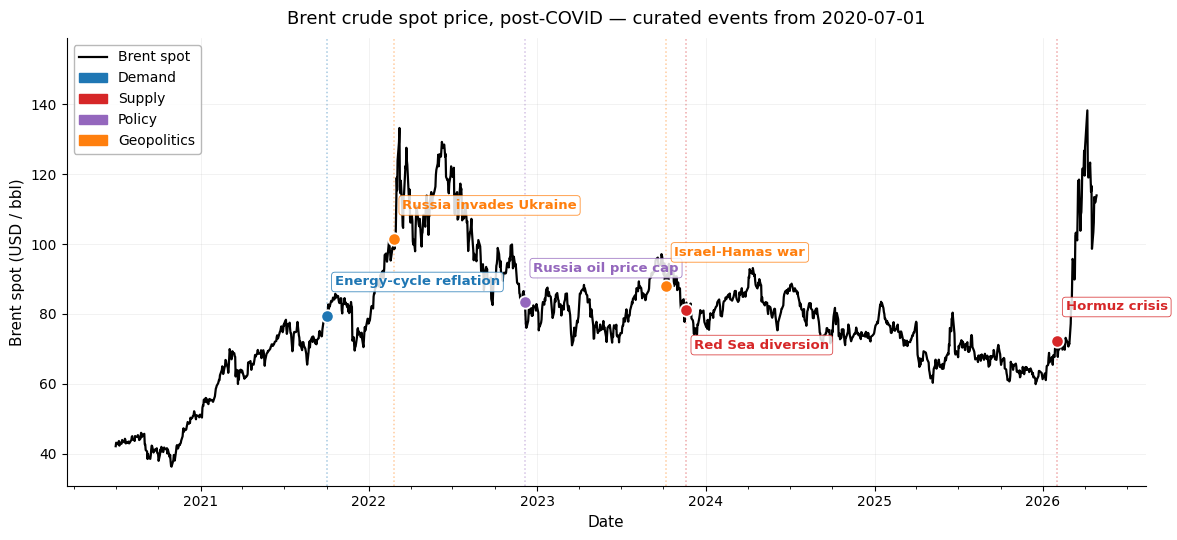

Last run: 2026-05-25 22:51:45


In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

POST_COVID_START = pd.Timestamp('2020-07-01')
PLOTS_DIR = ROOT / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

brent_post = brent.loc[POST_COVID_START:]
ev_post = ev[ev['date'] >= POST_COVID_START].copy().sort_values('date').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(brent_post.index, brent_post['Brent'], color='black', linewidth=1.6, zorder=2)

# Stagger label vertical offset for clustered events
label_dy = []
last_date = None
for _, e in ev_post.iterrows():
    if last_date is not None and (e['date'] - last_date).days < 90:
        label_dy.append(-28 if label_dy[-1] > 0 else 22)
    else:
        label_dy.append(22)
    last_date = e['date']

for (_, e), dy in zip(ev_post.iterrows(), label_dy):
    color = CATEGORY_COLOR[e['category']]
    ax.axvline(x=e['date'], color=color, linestyle=':', alpha=0.4, linewidth=1.1, zorder=1)
    ax.scatter([e['date']], [e['price']], color=color, s=80, zorder=5,
               edgecolor='white', linewidth=1.3)
    ax.annotate(e['label'], xy=(e['date'], e['price']), xytext=(6, dy),
                textcoords='offset points', fontsize=9.5, color=color,
                fontweight='semibold',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor=color, alpha=0.85, linewidth=0.6))

handles = [Line2D([0], [0], color='black', linewidth=1.6, label='Brent spot')]
for cat in ['demand', 'supply', 'policy', 'geopolitics']:
    if cat in ev_post['category'].unique():
        handles.append(Patch(color=CATEGORY_COLOR[cat], label=cat.capitalize()))
ax.legend(handles=handles, loc='upper left', frameon=True, framealpha=0.92,
          fontsize=10, edgecolor='0.7')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Brent spot (USD / bbl)', fontsize=11)
ax.set_title(f'Brent crude spot price, post-COVID — curated events from {POST_COVID_START.date()}',
             fontsize=13, pad=10)
ax.grid(alpha=0.22, linestyle='-', linewidth=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylim(brent_post['Brent'].min() * 0.85, brent_post['Brent'].max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()

out_path = PLOTS_DIR / 'eda_brent_events_postcovid.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## Plot 2 — Brent + 21 audited donors per focal event, indexed to T₀

One panel per focal event (Russia 2022, Hormuz 2026). Each panel shows Brent and the **21-donor strict-clean intersection** from [donor_catalog.md](../docs/donor_catalog.md) (the preferred SCM specification — drops the Russia H-tier and M-tier). The window for each event starts at its pre-window start (Russia: `2020-07-01`; Hormuz: `2024-06-01`) and extends through the latest data. **All series are rebased to 100 at the pre-window start**, and the **x-axis is days from T₀** so the event date is at 0.

Only the focal event itself is marked (vertical dashed line at day 0); non-focal events from `historical_events.csv` are not overlaid.

**What to look for.** In the pre-window the audited donors should track Brent — that is the co-movement SCM exploits to build the synthetic. At and after T₀, Brent should separate from the synthetic envelope formed by the donors (the visual analog of the SCM gap). If donors *also* jump at T₀, the donor pool would be contaminated — which the audit was specifically designed to prevent.

In [20]:
# 21-donor strict-clean intersection (preferred SCM specification)
# Per donor_catalog.md: drops Russia H-tier (Wheat, Corn, Palladium, EUR, DXY, BTC)
# and Russia M-tier (Copper, IronOre, Soybeans, EM_Eq, GBP, US10Y).
AUDITED_DONORS = [
    'Silver', 'Platinum', 'Gold',                            # Metals (3 of 6)
    'Coffee', 'Sugar', 'Cotton', 'LiveCattle',               # Agriculturals (4 of 7)
    'SP500', 'WorldEq', 'Nikkei',                            # Equities (3 of 4)
    'AUD', 'JPY', 'CHF', 'CNY', 'INR', 'KRW', 'ZAR', 'MXN',  # FX (8 of 11)
    'TLT', 'HYG',                                            # Rates/credit (2 of 3)
    'VIX',                                                   # Volatility (1 of 1)
]
assert len(AUDITED_DONORS) == 21, f'expected 21 donors, got {len(AUDITED_DONORS)}'
missing = [d for d in AUDITED_DONORS if d not in donors.columns]
assert not missing, f'audited donors missing from data: {missing}'

# post_end mirrors lib/config.POST_END:
#   Russia truncated to 2022-09-30 (before OPEC+'s 2022-10-05 announcement of a
#   2 mb/d cut, which confounds the post-invasion premium estimate).
#   Hormuz extends to latest data available.
FOCAL_EVENTS = [
    {'name': 'Russia invades Ukraine',
     'slug': 'russia',
     'T0':        pd.Timestamp('2022-02-24'),
     'pre_start': pd.Timestamp('2020-07-01'),
     'post_end':  pd.Timestamp('2022-09-30')},
    {'name': 'Strait of Hormuz crisis',
     'slug': 'hormuz',
     'T0':        pd.Timestamp('2026-02-01'),
     'pre_start': pd.Timestamp('2024-06-01'),
     'post_end':  pd.Timestamp('2026-05-01')},
]

def build_event_panel(event, brent, donors, audited):
    """Pre-window start to post_end (clipped to data availability);
    rebased to 100 at the first in-window date."""
    data = (brent[['Brent']].join(donors[audited], how='outer')
                            .sort_index()
                            .loc[event['pre_start']:event['post_end']])
    data = data.ffill(limit=5).dropna()
    if data.empty:
        return None
    base = data.iloc[0]
    norm = 100 * data.divide(base)
    norm['_days_from_T0'] = (norm.index - event['T0']).days
    return norm

for event in FOCAL_EVENTS:
    panel = build_event_panel(event, brent, donors, AUDITED_DONORS)
    if panel is None:
        print(f"{event['name']:30s}  panel empty")
    else:
        first = panel.index.min().date()
        last  = panel.index.max().date()
        d0, d1 = panel['_days_from_T0'].iloc[0], panel['_days_from_T0'].iloc[-1]
        print(f"{event['name']:30s}  {first} -> {last}  "
              f"(days from T0: {d0} -> {d1})  shape {panel.shape[0]}x{panel.shape[1]-1}")

Russia invades Ukraine          2020-07-01 -> 2022-09-30  (days from T0: -603 -> 218)  shape 822x22
Strait of Hormuz crisis         2024-06-03 -> 2026-05-01  (days from T0: -608 -> 89)  shape 697x22
Last run: 2026-05-25 22:51:45


In [21]:
import plotly.express as px

audited_palette = dict(zip(AUDITED_DONORS,
                           (px.colors.qualitative.Dark24 + px.colors.qualitative.Light24)[:21]))

def make_event_plot(event, brent, donors, audited):
    panel = build_event_panel(event, brent, donors, audited)
    if panel is None:
        return None

    x = panel['_days_from_T0']
    fig = go.Figure()

    for col in audited:
        fig.add_trace(go.Scatter(
            x=x, y=panel[col], mode='lines', name=col,
            line=dict(width=1.0, color=audited_palette[col]),
            opacity=0.78,
            hovertemplate=(f'<b>{col}</b><br>%{{x}}d from T₀ '
                           f'(%{{customdata|%Y-%m-%d}})<br>Index: %{{y:.1f}}<extra></extra>'),
            customdata=panel.index,
        ))

    fig.add_trace(go.Scatter(
        x=x, y=panel['Brent'], mode='lines', name='Brent',
        line=dict(color='black', width=2.6),
        hovertemplate=('<b>Brent</b><br>%{x}d from T₀ '
                       '(%{customdata|%Y-%m-%d})<br>Index: %{y:.1f}<extra></extra>'),
        customdata=panel.index,
    ))

    fig.add_vline(x=0, line_width=1.6, line_dash='dash',
                  line_color='black', opacity=0.7,
                  annotation_text=f"T₀ = {event['T0'].date()}",
                  annotation_position='top right',
                  annotation_font=dict(size=11, color='black'))

    fig.update_layout(
        title=(f"{event['name']} — Brent vs 21 audited donors "
               f"(rebased to 100 at {event['pre_start'].date()})"),
        xaxis_title=f"Days from T₀ ({event['T0'].date()})",
        yaxis_title=f"Index (pre-window start {event['pre_start'].date()} = 100)",
        template='plotly_white', hovermode='x unified',
        height=620,
        legend=dict(orientation='v', y=1.0, x=1.02, xanchor='left'),
        margin=dict(t=80, b=60, l=70, r=170),
    )
    return fig

for event in FOCAL_EVENTS:
    fig = make_event_plot(event, brent, donors, AUDITED_DONORS)
    if fig is not None:
        fig.show()

Last run: 2026-05-25 22:51:45


Saved: /Users/cherrylchico/Desktop/BSE/T3/Thesis/Brent_Analysis/plots/eda_donors_audited_russia.png


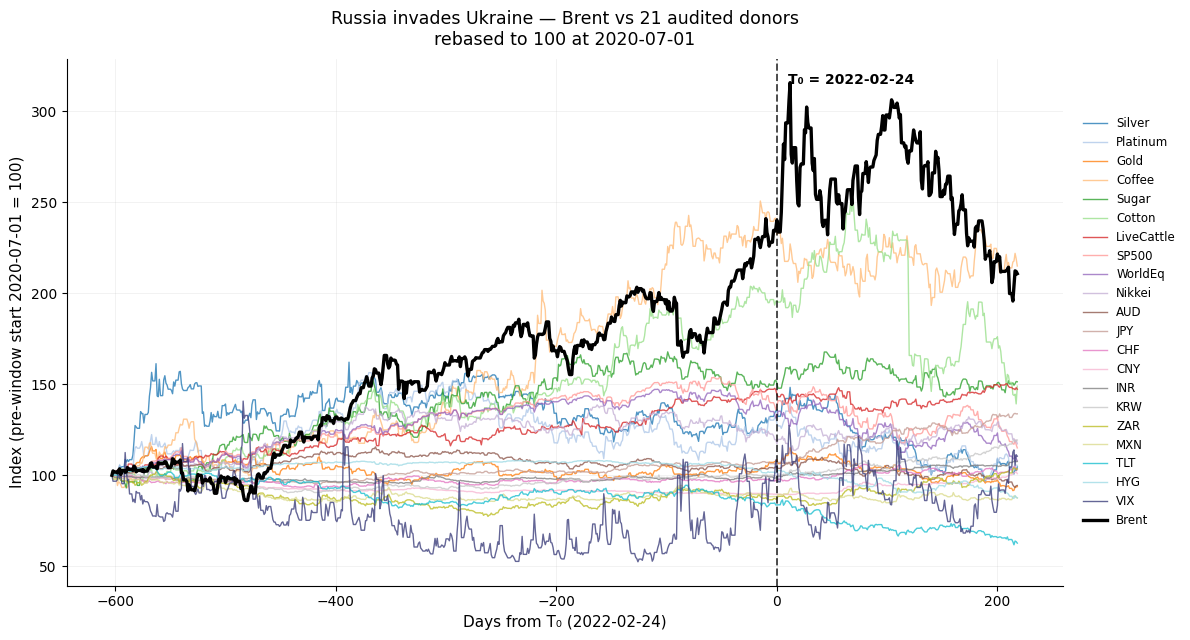

Saved: /Users/cherrylchico/Desktop/BSE/T3/Thesis/Brent_Analysis/plots/eda_donors_audited_hormuz.png


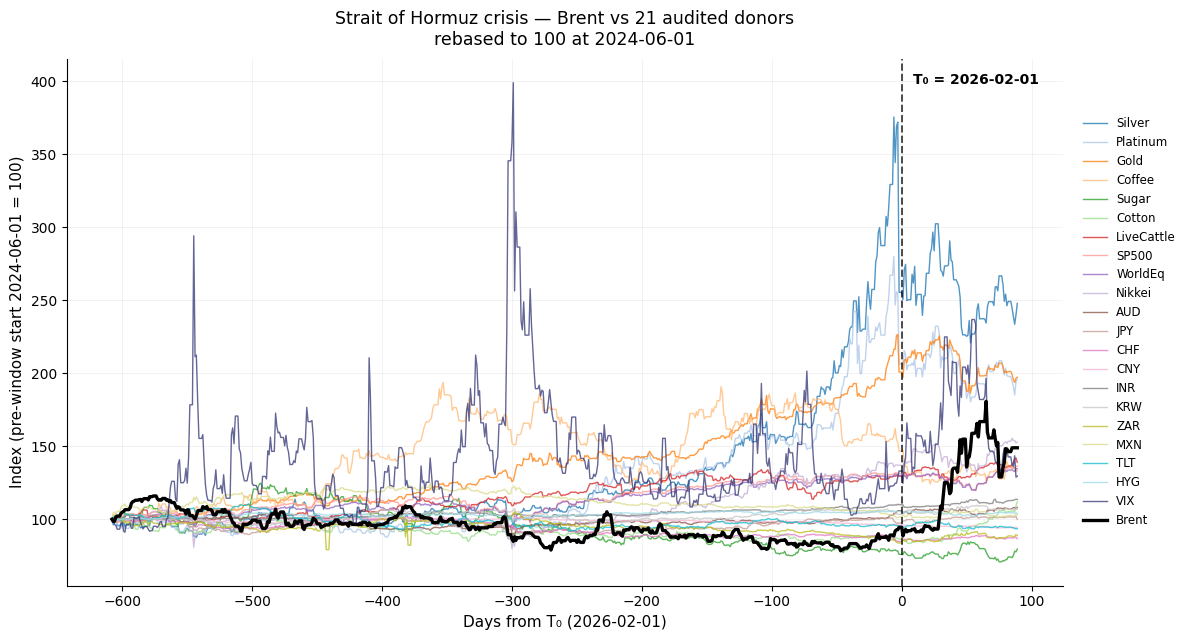

Last run: 2026-05-25 22:51:46


In [22]:
# Static matplotlib export of the per-event audited-donor plots for presentation.
# Mirrors the plotly figures above but writes PNGs to plots/.

def save_event_plot_static(event, brent, donors, audited, out_dir):
    panel = build_event_panel(event, brent, donors, audited)
    if panel is None:
        return None

    x = panel['_days_from_T0'].values

    # 21 visually distinct colours: tab20 + a few from tab20b
    cmap20  = plt.get_cmap('tab20').colors
    cmap20b = plt.get_cmap('tab20b').colors
    palette = list(cmap20) + list(cmap20b)
    colors = palette[:len(audited)]

    fig, ax = plt.subplots(figsize=(12, 6.5))

    for col, color in zip(audited, colors):
        ax.plot(x, panel[col].values, color=color, linewidth=1.0,
                alpha=0.78, label=col)
    ax.plot(x, panel['Brent'].values, color='black', linewidth=2.4,
            label='Brent', zorder=10)

    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.4,
               alpha=0.7, zorder=8)
    ymin, ymax = ax.get_ylim()
    ax.annotate(f"T₀ = {event['T0'].date()}",
                xy=(0, ymax), xytext=(8, -10),
                textcoords='offset points', fontsize=10,
                ha='left', va='top', fontweight='semibold')

    ax.set_xlabel(f"Days from T₀ ({event['T0'].date()})", fontsize=11)
    ax.set_ylabel(f"Index (pre-window start {event['pre_start'].date()} = 100)",
                  fontsize=11)
    ax.set_title(f"{event['name']} — Brent vs 21 audited donors\n"
                 f"rebased to 100 at {event['pre_start'].date()}",
                 fontsize=12.5, pad=10)
    ax.grid(alpha=0.22, linestyle='-', linewidth=0.5)
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
              frameon=False, fontsize=8.5, ncol=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()

    out_path = out_dir / f"eda_donors_audited_{event['slug']}.png"
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f'Saved: {out_path}')
    plt.show()
    return out_path

for event in FOCAL_EVENTS:
    save_event_plot_static(event, brent, donors, AUDITED_DONORS, PLOTS_DIR)

Saved: /Users/cherrylchico/Desktop/BSE/T3/Thesis/Brent_Analysis/plots/eda_donors_audited_side_by_side.png


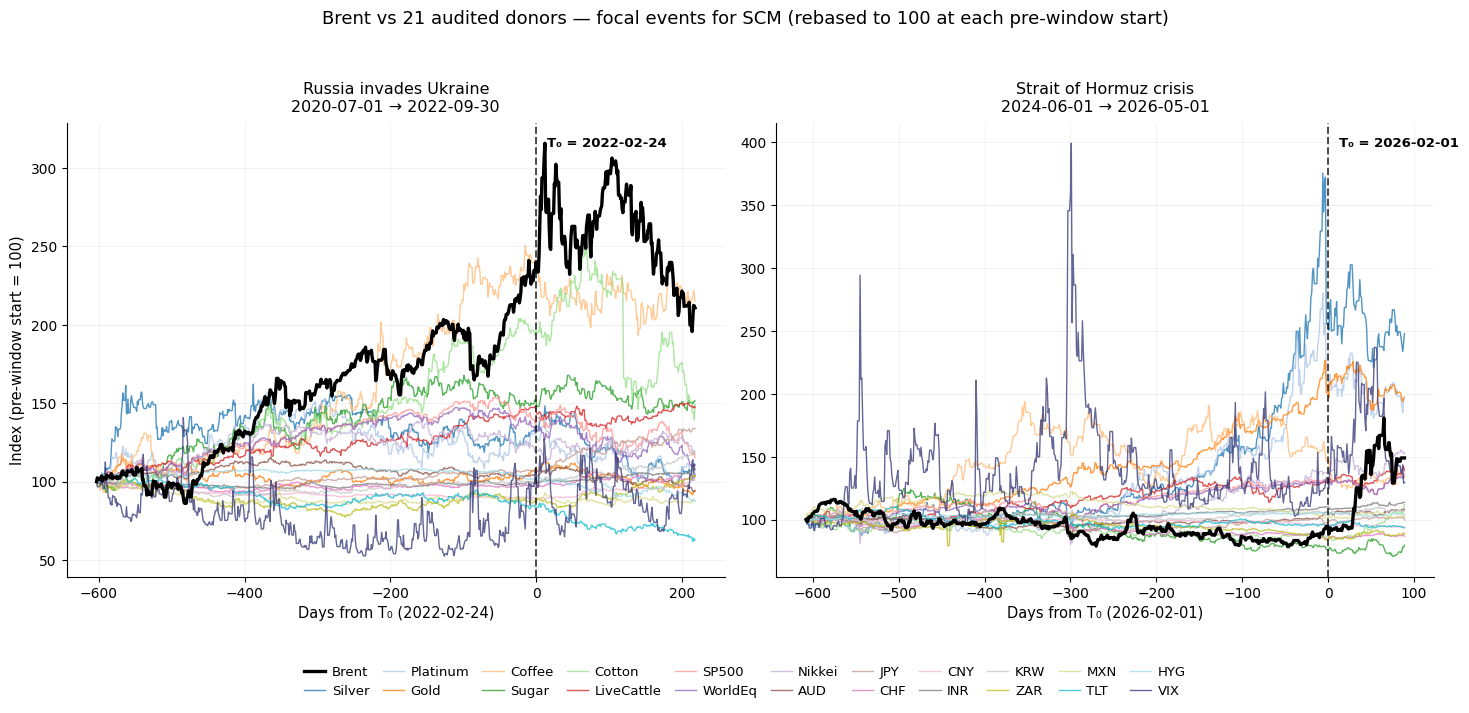

PosixPath('/Users/cherrylchico/Desktop/BSE/T3/Thesis/Brent_Analysis/plots/eda_donors_audited_side_by_side.png')

Last run: 2026-05-25 22:51:46


In [23]:
# Side-by-side static export for the presentation. One figure, two panels,
# one shared bottom legend that applies to both panels (same 21-donor palette).

def save_side_by_side(events, brent, donors, audited, out_dir):
    panels = [(e, build_event_panel(e, brent, donors, audited)) for e in events]
    if any(p is None for _, p in panels):
        print('one or more panels empty; skipping side-by-side export')
        return None

    cmap20  = plt.get_cmap('tab20').colors
    cmap20b = plt.get_cmap('tab20b').colors
    palette = list(cmap20) + list(cmap20b)
    color_map = dict(zip(audited, palette[:len(audited)]))

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    legend_handles, legend_labels = [], []

    for i, (ax, (event, panel)) in enumerate(zip(axes, panels)):
        x = panel['_days_from_T0'].values
        for col in audited:
            line, = ax.plot(x, panel[col].values, color=color_map[col],
                            linewidth=1.0, alpha=0.78, label=col)
            if i == 0:
                legend_handles.append(line)
                legend_labels.append(col)
        brent_line, = ax.plot(x, panel['Brent'].values, color='black',
                              linewidth=2.4, label='Brent', zorder=10)
        if i == 0:
            legend_handles.insert(0, brent_line)
            legend_labels.insert(0, 'Brent')

        ax.axvline(x=0, color='black', linestyle='--', linewidth=1.4,
                   alpha=0.7, zorder=8)
        ymin, ymax = ax.get_ylim()
        ax.annotate(f"T₀ = {event['T0'].date()}",
                    xy=(0, ymax), xytext=(8, -10),
                    textcoords='offset points', fontsize=9.5,
                    ha='left', va='top', fontweight='semibold')

        ax.set_xlabel(f"Days from T₀ ({event['T0'].date()})", fontsize=10.5)
        ax.set_title(f"{event['name']}\n"
                     f"{event['pre_start'].date()} → {event['post_end'].date()}",
                     fontsize=11.5, pad=8)
        ax.grid(alpha=0.22, linestyle='-', linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[0].set_ylabel('Index (pre-window start = 100)', fontsize=10.5)

    # Shared bottom legend: 22 items in 11 columns × 2 rows
    fig.legend(legend_handles, legend_labels,
               loc='lower center', bbox_to_anchor=(0.5, -0.005),
               frameon=False, fontsize=9.5, ncol=11,
               columnspacing=1.0, handlelength=1.6, handletextpad=0.5)

    fig.suptitle('Brent vs 21 audited donors — focal events for SCM '
                 '(rebased to 100 at each pre-window start)',
                 fontsize=13, y=0.995)
    # Leave bottom margin for the legend (~10% of figure height)
    fig.tight_layout(rect=[0, 0.10, 1, 0.96])

    out_path = out_dir / 'eda_donors_audited_side_by_side.png'
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f'Saved: {out_path}')
    plt.show()
    return out_path

save_side_by_side(FOCAL_EVENTS, brent, donors, AUDITED_DONORS, PLOTS_DIR)

## Plot 3 — Event-window response: Brent vs donors

For each event in the donor coverage window, compute the percent change over a [-5, +10] business-day window around the event date for Brent and for every donor. The heatmap below makes contamination visible at a glance.

**Reading the heatmap:** rows = events grouped by category. Columns = Brent + 12 donors. A clean donor pool should show large Brent moves on `supply`/`policy` rows with **small** donor moves; on `demand` rows Brent and donors should both move.

In [24]:
PRE_DAYS, POST_DAYS = 5, 10

def event_window_return(series, event_date, pre=PRE_DAYS, post=POST_DAYS):
    s = series.dropna()
    if len(s) == 0:
        return np.nan
    pre_d  = event_date - pd.tseries.offsets.BDay(pre)
    post_d = event_date + pd.tseries.offsets.BDay(post)
    if pre_d < s.index.min() or post_d > s.index.max():
        return np.nan
    pre_v  = s.loc[:pre_d].iloc[-1]
    post_v = s.loc[:post_d].iloc[-1]
    return 100.0 * (post_v / pre_v - 1.0)

rows = []
for _, e in events.iterrows():
    row = {'date': e['date'].date(), 'event': e['label'], 'category': e['category']}
    row['Brent'] = event_window_return(brent['Brent'], e['date'])
    for col in donors.columns:
        row[col] = event_window_return(donors[col], e['date'])
    rows.append(row)

resp = pd.DataFrame(rows)
resp = resp.sort_values(['category', 'date']).reset_index(drop=True)
resp.round(2)

,date,event,category,Brent,Copper,IronOre,Silver,Platinum,Palladium,Gold,...,INR,KRW,ZAR,MXN,DXY,US10Y,TLT,HYG,VIX,BTC
0,2001-09-11,9/11,demand,-23.37,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008-07-11,Brent peak $147,demand,-13.37,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2008-09-15,Lehman / GFC,demand,-5.07,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-03-11,COVID-19 pandemic,demand,-50.60,-13.84,-0.96,-13.67,-14.71,-5.20,-0.54,...,5.34,3.56,13.61,27.47,3.81,-13.51,5.09,-15.67,99.91,-23.69
4,2021-10-01,Energy-cycle reflation,demand,9.36,10.41,2.57,4.20,7.73,6.58,1.00,...,1.56,0.63,0.18,2.44,0.65,7.95,-1.28,-0.78,-8.17,43.78
5,2003-03-20,Iraq War,geopolitics,-21.28,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2010-12-17,Arab Spring begins,geopolitics,4.12,8.15,-0.41,8.17,6.17,9.84,2.66,...,-0.53,-0.82,-3.50,-0.90,-1.30,0.27,1.04,1.01,0.79,NaN
7,2022-02-24,Russia invades Ukraine,geopolitics,20.21,2.62,9.08,9.75,0.29,23.78,5.12,...,1.46,2.21,0.06,3.05,2.83,1.98,-1.70,-1.51,7.54,-2.71
8,2023-10-07,Israel-Hamas war,geopolitics,2.75,-2.48,-1.24,10.05,2.26,-8.39,8.33,...,0.11,0.32,0.65,5.25,-0.69,5.15,-4.24,-1.32,23.28,7.82
9,2012-07-01,EU Iran embargo,policy,14.91,5.63,-0.96,-0.63,-0.46,-3.60,0.26,...,-2.08,-0.63,-0.90,-4.35,1.02,-6.78,1.84,1.18,-17.86,NaN


Last run: 2026-05-25 22:51:47


In [25]:
asset_cols = ['Brent'] + list(donors.columns)
resp_plot = resp.dropna(subset=['Brent']).reset_index(drop=True)
Z = resp_plot[asset_cols].values
y_labels = [f"[{r['category'][:4]}] {r['event']}  ({r['date']})" for _, r in resp_plot.iterrows()]

fig = go.Figure(go.Heatmap(
    z=Z, x=asset_cols, y=y_labels,
    colorscale='RdBu_r', zmid=0,
    colorbar=dict(title='% change'),
    hovertemplate='<b>%{y}</b><br>%{x}: %{z:.2f}%<extra></extra>',
    text=np.round(Z, 1), texttemplate='%{text}', textfont=dict(size=9),
))
fig.update_layout(
    title=f'Event-window return [-{PRE_DAYS}d, +{POST_DAYS}d business days] \u2014 Brent vs donors',
    template='plotly_white', height=max(500, 26 * len(resp_plot) + 140),
    margin=dict(t=70, b=40, l=280, r=40),
    xaxis=dict(side='top'),
)
fig.show()

Last run: 2026-05-25 22:51:47


## Plot 4 — Brent + GPR overlay

Caldara-Iacoviello daily Geopolitical Risk index (30-day MA) plotted against Brent. Useful sanity check: GPR should spike on `geopolitics` and `supply` events tied to MENA, and these spikes should not appear in the donors panel above.

In [26]:
gpr_ma = gpr['GPRD'].rolling(30, min_periods=10).mean()

fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Scatter(
    x=brent.index, y=brent['Brent'], name='Brent', mode='lines',
    line=dict(color='black', width=1.4),
), secondary_y=False)
fig.add_trace(go.Scatter(
    x=gpr_ma.index, y=gpr_ma.values, name='GPR (30d MA)', mode='lines',
    line=dict(color='orange', width=1.2, dash='dash'),
), secondary_y=True)

for _, e in ev.iterrows():
    fig.add_vline(x=e['date'], line_width=1, line_dash='dot',
                  line_color=CATEGORY_COLOR[e['category']], opacity=0.25)

fig.update_yaxes(title_text='Brent (USD/bbl)', secondary_y=False)
fig.update_yaxes(title_text='GPR (30-day MA)', secondary_y=True, showgrid=False)
fig.update_layout(
    title='Brent and Geopolitical Risk index (Caldara-Iacoviello, 2022)',
    template='plotly_white', hovermode='x unified', height=520,
    legend=dict(orientation='h', y=-0.18, x=0, xanchor='left', yanchor='top'),
    margin=dict(t=70, b=80, l=70, r=70),
)
fig.show()

Last run: 2026-05-25 22:51:48


## Reading the result

Two things to take from this notebook into the SCM in `02_SCM_Regression.ipynb`:

1. **Pre-period selection.** The donor-coverage window starts mid-2014 (URTH, after iron ore futures launch). The analysis uses 2020-06-01 → 2026-05-01 as the analysis frame; the EDA confirms this avoids the 2014–2016 OPEC price war and the 2018 JCPOA exit, both of which would distort donor weights.
2. **Donor-pool defensibility.** Inspect the heatmap rows tagged `supply` / `policy`. If the donor cells are uniformly pale (small moves) while the Brent cell is red/blue (large move), the SCM identifying assumption is supported. If donor cells are dark on these rows, the donor pool needs revision.